# GSE189903: PGAM5 RNA detection in HCC tumor macrophages

## Scope and methods

User-selected scope: **Hepatocellular carcinoma, Tumor core or Tumor border only**. Adjacent non-tumor tissues and intrahepatic cholangiocarcinoma are excluded. Official GEO family SOFT cancer/tissue characteristics map to S_ID in Info.txt. Author TAM labels define macrophages. There are 16 eligible samples from four HCC patients; samples are separate regional specimens, not independent patients.

PGAM5 raw UMI count >0 defines detected cells, count=0 defines RNA nondetection, not protein negativity. QC retains >=500 detected genes and <20% mitochondrial counts. Counts are normalized to 10,000 per cell and log1p transformed. All selected QC TAMs are pooled for Wilcoxon with tie correction; BH adjustment is across all genes. Following the requested analysis, no patient pairing, depth matching or sample/depth covariates are used.

Thresholds: **FDR <0.05, |Scanpy approximate log2FC| >=1, >=10% detection in either group**. PGAM5 is retained in full and threshold-passing tables, and excluded from up/down candidate lists. Ribosomal and mitochondrial genes remain eligible. Approximate log2FC is the ratio of back-transformed mean log expression, not arithmetic mean expression; folds against near-zero controls may be pseudocount sensitive.

Candidates are exploratory associations. Cell-level FDR does not demonstrate reproducibility across patients. The requested pooled model does not adjust for tumor region, patient, subtype or sequencing depth. No validated signature, causal mechanism, ambient-RNA correction or doublet removal is claimed.

Sources: [GEO GSE189903](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE189903), [official supplement directory](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE189nnn/GSE189903/suppl/), [family SOFT](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE189nnn/GSE189903/soft/GSE189903_family.soft.gz). PMID 36476645.

analyze_HCC_tumor.py has been executed on the official counts. This notebook verifies saved results against raw QC TAM counts and regenerates scientific PNG/PDF figures.


In [1]:
from pathlib import Path
import json
import numpy as np,pandas as pd,anndata as ad
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from IPython.display import display
R=Path.cwd();s=json.loads((R/'analysis_summary.json').read_text())
a=ad.read_h5ad(R/'HCC_tumor_TAM_counts_QC.h5ad')
r=pd.read_csv(R/'GSE189903_HCC_tumor_PGAM5_full_DE.csv',index_col=0)
u=pd.read_csv(R/'GSE189903_HCC_tumor_PGAM5_upregulated.csv',index_col=0)
d=pd.read_csv(R/'GSE189903_HCC_tumor_PGAM5_downregulated.csv',index_col=0)
m=pd.read_csv(R/'sample_diagnosis_tissue_mapping.csv')
assert int(m.included.sum())==16 and m[m.included].diagnosis.eq('Hepatocellular carcinoma').all()
assert m[m.included].tissue.isin(['Tumor core','Tumor border']).all()
assert a.obs.Type.eq('TAM').all() and a.obs.diagnosis.eq('Hepatocellular carcinoma').all()
assert a.obs.tissue.isin(['Tumor core','Tumor border']).all()
assert a.obs.n_genes.ge(500).all() and a.obs.pct_mt.lt(20).all()
assert a.obs_names.is_unique and a.var_names.is_unique
pg=np.flatnonzero(a.var.gene.eq('PGAM5'));assert len(pg)==1
pos=a.X[:,pg[0]].toarray().ravel()>0
assert np.array_equal(pos,a.obs.PGAM5_detected) and int(pos.sum())==s['PGAM5_positive_cells']
assert int((~pos).sum())==s['PGAM5_undetected_cells'] and len(a)==s['QC_TAMs']
assert np.allclose(multipletests(r.p_value,method='fdr_bh')[1],r.FDR,atol=1e-12)
eligible=r.FDR.lt(.05)&r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')
assert set(u.index)==set(r.index[eligible&r.log2FC.ge(1)])
assert set(d.index)==set(r.index[eligible&r.log2FC.le(-1)])
assert len(u)==s['upregulated_excluding_PGAM5'] and len(d)==s['downregulated_excluding_PGAM5']
checks=[];totals=np.asarray(a.X.sum(axis=1)).ravel()
for gene_id in u.index[:10]:
 j=a.var_names.get_loc(gene_id);counts=a.X[:,j].toarray().ravel();v=np.log1p(counts/totals*1e4)
 pv=mannwhitneyu(v[pos],v[~pos],alternative='two-sided',method='asymptotic',use_continuity=False).pvalue
 est=np.log2((np.expm1(v[pos].mean())+1e-9)/(np.expm1(v[~pos].mean())+1e-9))
 assert np.isclose(pv,r.loc[gene_id,'p_value'],rtol=.002,atol=1e-12)
 assert np.isclose(est,r.loc[gene_id,'log2FC'],atol=.002)
 assert np.isclose((counts[pos]>0).mean(),r.loc[gene_id,'fraction_PGAM5_positive'])
 checks.append({'gene':r.loc[gene_id,'gene'],'SciPy_two_sided_p':pv,'Scanpy_p':r.loc[gene_id,'p_value'],'recomputed_log2FC':est,'Scanpy_log2FC':r.loc[gene_id,'log2FC']})
pd.DataFrame(checks).to_csv(R/'independent_calculation_checks.csv',index=False)
print('Scope, raw grouping, QC, all candidate memberships, BH FDR and ten selected independent rank tests/fold changes verified.')
display(pd.DataFrame(checks))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.bbox':'tight'})


Scope, raw grouping, QC, all candidate memberships, BH FDR and ten selected independent rank tests/fold changes verified.


,gene,SciPy_two_sided_p,Scanpy_p,recomputed_log2FC,Scanpy_log2FC
0,NHP2,1.223480e-10,1.223480e-10,1.028845,1.028845
1,LINC01503,9.023752e-10,9.023752e-10,1.198399,1.198399
2,MRPL53,1.457413e-08,1.457413e-08,1.778823,1.778823
3,ECI1,5.803530e-08,5.803530e-08,1.128435,1.128435
4,NIP7,7.681294e-08,7.681294e-08,1.406955,1.406955
5,MAP1S,8.967077e-08,8.967077e-08,1.024236,1.024236
6,FAM104A,1.252642e-07,1.252642e-07,1.142711,1.142711
7,NBEAL2,1.474268e-07,1.474268e-07,1.303469,1.303469
8,ATG4A,1.815529e-07,1.815529e-07,1.311262,1.311262
9,NCK2,2.205042e-07,2.205042e-07,1.843066,1.843066


## Cohort and per-sample support

All reported gene tests pool cells across selected samples; descriptive patient/region tables do not introduce patient-paired tests. PGAM5 detection rates have QC TAMs as their denominators.


,value
HCC_tumor_samples,16
HCC_tumor_patients,4
HCC_tumor_cells,45194
HCC_tumor_sample_ids,"[1HB, 1HT1, 1HT2, 1HT3, 2HB, 2HT2, 3HB, 3HT1, ..."
HCC_selected_sample_tissues,"{'Tumor core': 12, 'Tumor border': 4}"
raw_TAMs,5047
QC_TAMs,4856
PGAM5_positive_cells,115
PGAM5_undetected_cells,4741
QC_samples_with_TAMs,16


,S_ID,Sample,patient,tissue
11,S012,1HB,1H,Tumor border
13,S014,1HT1,1H,Tumor core
14,S015,1HT2,1H,Tumor core
15,S016,1HT3,1H,Tumor core
16,S017,2HB,2H,Tumor border
18,S019,2HT2,2H,Tumor core
19,S020,3HB,3H,Tumor border
21,S022,3HT1,3H,Tumor core
22,S023,3HT2,3H,Tumor core
23,S024,3HT3,3H,Tumor core


,S_ID,Sample,patient,tissue,TAMs,PGAM5_positive,rate
0,S012,1HB,1H,Tumor border,43,0,0.000000
1,S014,1HT1,1H,Tumor core,187,8,0.042781
2,S015,1HT2,1H,Tumor core,69,2,0.028986
3,S016,1HT3,1H,Tumor core,43,2,0.046512
4,S017,2HB,2H,Tumor border,226,3,0.013274
5,S019,2HT2,2H,Tumor core,112,0,0.000000
6,S020,3HB,3H,Tumor border,144,2,0.013889
7,S022,3HT1,3H,Tumor core,137,2,0.014599
8,S023,3HT2,3H,Tumor core,181,6,0.033149
9,S024,3HT3,3H,Tumor core,309,3,0.009709


,patient,tissue,TAMs,PGAM5_positive,rate
0,1H,Tumor border,43,0,0.000000
1,1H,Tumor core,299,12,0.040134
2,2H,Tumor border,226,3,0.013274
3,2H,Tumor core,282,6,0.021277
4,3H,Tumor border,144,2,0.013889
5,3H,Tumor core,627,11,0.017544
6,4H,Tumor border,283,8,0.028269
7,4H,Tumor core,2952,73,0.024729


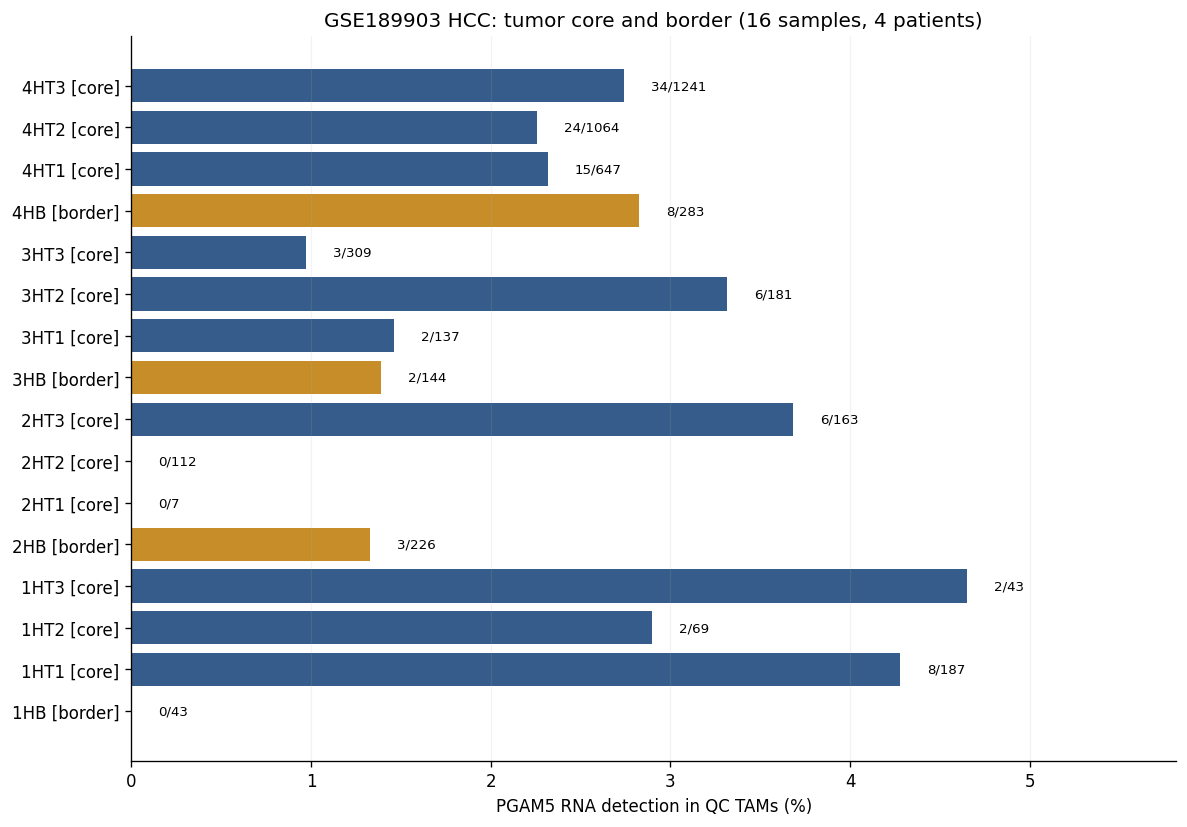

In [2]:
display(pd.Series(s,name='value').to_frame())
display(m[m.included][['S_ID','Sample','patient','tissue']])
samples=pd.read_csv(R/'PGAM5_by_sample.csv');display(samples)
display(pd.read_csv(R/'PGAM5_by_patient_tissue.csv'))
fig,ax=plt.subplots(figsize=(10,7))
t=samples.sort_values(['patient','Sample']).reset_index(drop=True)
labels=t.Sample+' ['+t.tissue.str.replace('Tumor ','',regex=False)+']'
ax.barh(labels,t.rate*100,color=np.where(t.tissue.eq('Tumor core'),'#355C8A','#C68D29'))
for i,z in t.iterrows():ax.text(z.rate*100+.15,i,f'{z.PGAM5_positive}/{z.TAMs}',va='center',fontsize=8)
ax.set_xlim(0,max(5,t.rate.max()*100*1.25));ax.set_xlabel('PGAM5 RNA detection in QC TAMs (%)')
ax.set_title('GSE189903 HCC: tumor core and border (16 samples, 4 patients)')
ax.grid(axis='x',alpha=.15);fig.tight_layout()
fig.savefig(R/'PGAM5_detection_by_sample.png');fig.savefig(R/'PGAM5_detection_by_sample.pdf');plt.show()


## Differential expression

The volcano includes genes detected in >=10% of either group and excludes PGAM5. Orange marks upregulated candidates, blue marks downregulated candidates, and gray marks the remainder. Dashed lines indicate the FDR and fold thresholds.


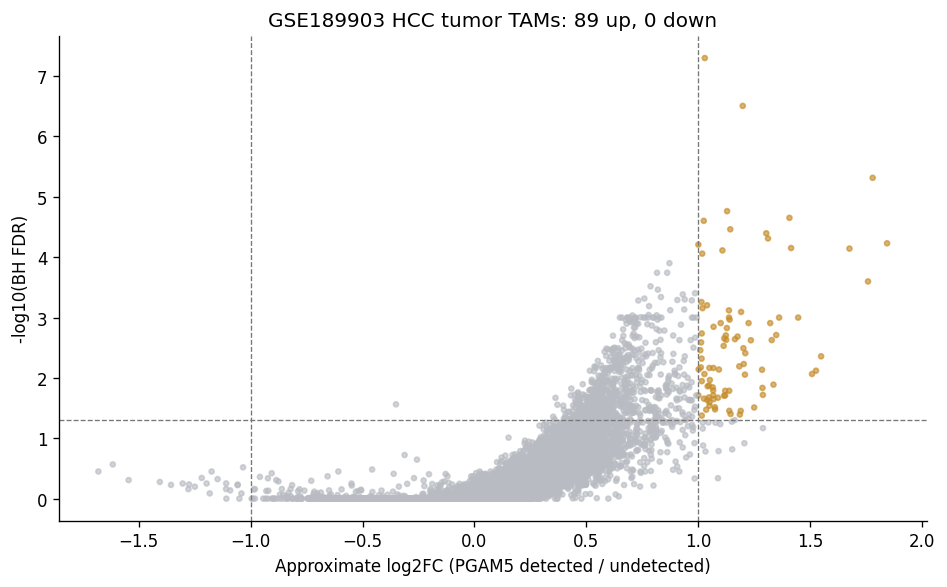

,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,
ENSG00000145912,NHP2,1.028845,5.014319e-08,0.791304,0.463615
ENSG00000233901,LINC01503,1.198399,3.114398e-07,0.295652,0.104619
ENSG00000204822,MRPL53,1.778823,4.836555e-06,0.121739,0.028686
ENSG00000167969,ECI1,1.128435,1.726717e-05,0.243478,0.089011
ENSG00000132603,NIP7,1.406955,2.228120e-05,0.278261,0.113689
ENSG00000130479,MAP1S,1.024236,2.495836e-05,0.391304,0.183084
ENSG00000133193,FAM104A,1.142711,3.449429e-05,0.313043,0.134782
ENSG00000160796,NBEAL2,1.303469,4.016993e-05,0.226087,0.083316
ENSG00000101844,ATG4A,1.311262,4.895308e-05,0.173913,0.055052


,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,


In [3]:
q=r[r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')]
color=np.where(q.FDR.lt(.05)&q.log2FC.ge(1),'#C68D29',np.where(q.FDR.lt(.05)&q.log2FC.le(-1),'#355C8A','#B8BCC2'))
fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(q.log2FC,-np.log10(q.FDR.clip(lower=1e-300)),c=color,s=9,alpha=.65)
ax.axhline(-np.log10(.05),ls='--',color='#777',lw=.8)
for x in [-1,1]:ax.axvline(x,ls='--',color='#777',lw=.8)
ax.set_xlabel('Approximate log2FC (PGAM5 detected / undetected)');ax.set_ylabel('-log10(BH FDR)')
ax.set_title(f'GSE189903 HCC tumor TAMs: {len(u)} up, {len(d)} down')
fig.tight_layout();fig.savefig(R/'differential_expression.png');fig.savefig(R/'differential_expression.pdf');plt.show()
display(u[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))
display(d[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))


## Macrophage annotation checks

Original TAM labels define the analyzed population. Detection fractions for macrophage and nonmyeloid transcripts are retained without post hoc filtering; these checks do not demonstrate that all cells are singlets or free of ambient RNA.


group,PGAM5_detected,PGAM5_undetected
gene,,
ALB,0.287,0.222
APOA1,0.035,0.051
C1QA,0.870,0.834
C1QB,0.852,0.803
C1QC,0.826,0.793
CD3D,0.043,0.041
CD68,0.896,0.860
CSF1R,0.791,0.728
EPCAM,0.009,0.004


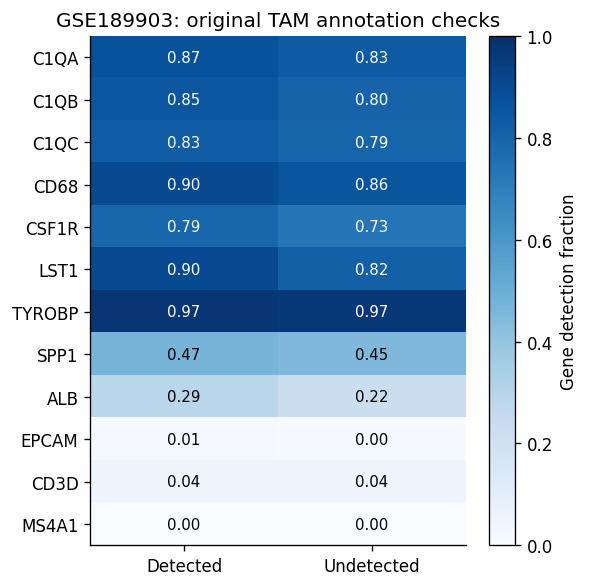

In [4]:
qa=pd.read_csv(R/'TAM_marker_QA.csv').pivot(index='gene',columns='group',values='fraction')
display(qa.round(3))
q=qa.reindex(['C1QA','C1QB','C1QC','CD68','CSF1R','LST1','TYROBP','SPP1','ALB','EPCAM','CD3D','MS4A1'])
fig,ax=plt.subplots(figsize=(5,5))
im=ax.imshow(q.to_numpy(),vmin=0,vmax=1,cmap='Blues',aspect='auto');ax.set_yticks(range(len(q)),q.index);ax.set_xticks([0,1],['Detected','Undetected'])
for i in range(len(q)):
 for j in range(2):
  z=q.iloc[i,j];ax.text(j,i,f'{z:.2f}',ha='center',va='center',color='white' if z>.6 else 'black',fontsize=9)
ax.set_title('GSE189903: original TAM annotation checks');fig.colorbar(im,ax=ax,label='Gene detection fraction')
fig.tight_layout();fig.savefig(R/'TAM_marker_QA.png');fig.savefig(R/'TAM_marker_QA.pdf');plt.show()


## Interpretation and reproduction

Reported genes are PGAM5 RNA detection-associated candidates under the requested model. They are not a validated macrophage-specific signature. Patient, region, subtype and depth confounding remain possible because the requested test does not adjust for them.

Download matrix, genes, barcodes, Info.txt and family SOFT from the official GEO URLs into the script directory. Install versions in environment_versions.txt, run python analyze_HCC_tumor.py, then python build_notebook.py. Scripts locate inputs relative to themselves. The downloadable ZIP includes tables, scripts, plots, input hashes and executed notebook outputs; full source matrices and QC count matrices remain in the cloud workspace and are regenerated by the analysis script.
